In [1]:
from brian2 import *
import matplotlib as plt
import numpy as np

Text(0, 0.5, 'voltage (mV)')

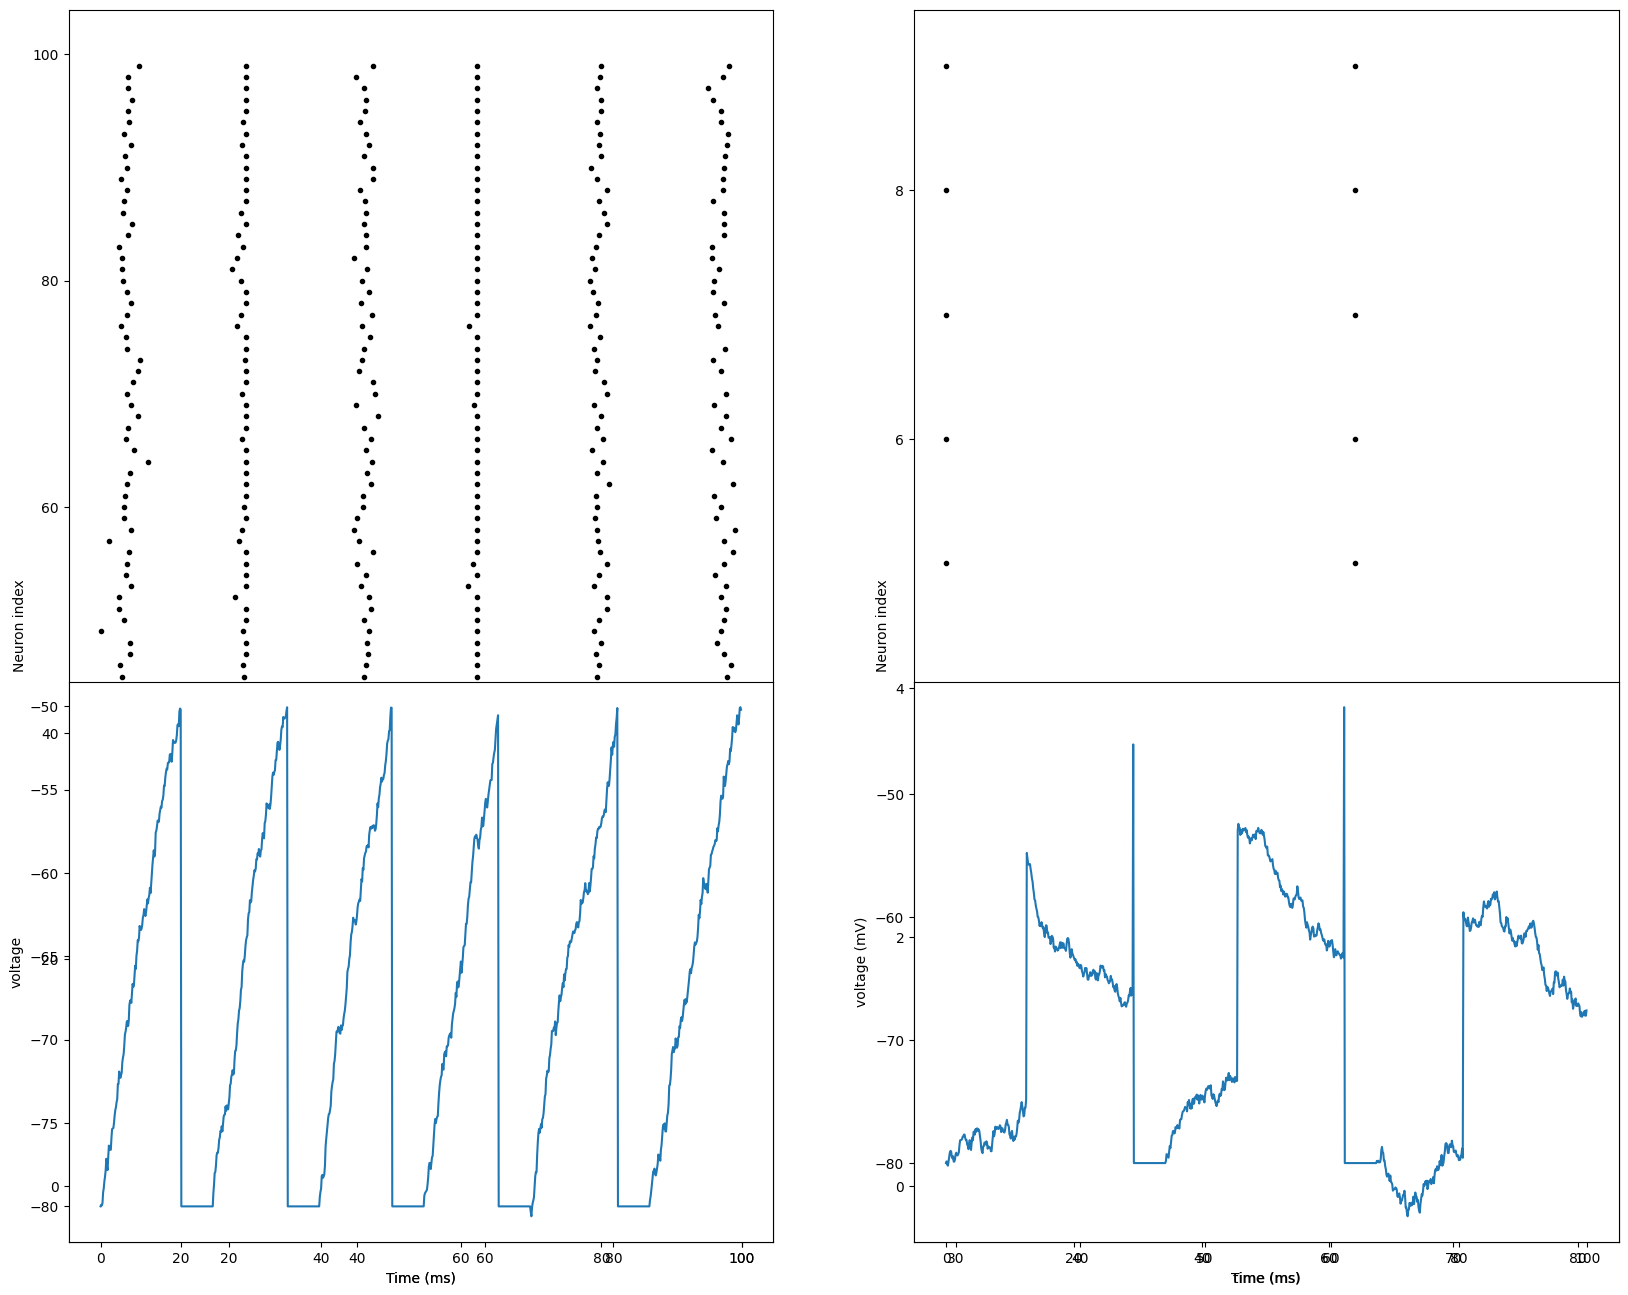

In [14]:
start_scope()


threshold = -50*mV
reset = -80*mV

Cm = 200 * pF       # membrane capacitance
gl = 10 * nS        # leak conductance
El = -70 * mV       # resting potential
w = 20*mV           # Synapse voltage
q = 2*mV
z = 0.5*mV

tau = 10*mS


eqs = '''
dv/dt = ((gl*(El - v)) + I)/Cm + sigma*xi/sqrt(ms) : volt (unless refractory)
I: amp
sigma:volt
'''


# Cortical neuron population
Cortical_neurons = NeuronGroup(
    100,
    model=eqs,
    reset='v = reset',
    threshold='v > threshold',
    refractory=5*ms,
    method='euler'
)

Thalamic_neurons = NeuronGroup(
    10, 
    model = eqs, 
    reset='v=reset', 
    threshold='v>threshold', 
    refractory = 5*ms, 
    method = 'euler')



# Monitors
CM = StateMonitor(Cortical_neurons, variables=['v'], record=True)
CS = SpikeMonitor(Cortical_neurons)

TM = StateMonitor(Thalamic_neurons, variables=['v'], record=True)
TS = SpikeMonitor(Thalamic_neurons)

C_to_T = Synapses(Cortical_neurons, Thalamic_neurons, on_pre='v += w')
C_to_T.connect(condition = 'j//10 == i')

T_to_C = Synapses(Thalamic_neurons, Cortical_neurons, on_pre='v+=q')
T_to_C.connect()

C_to_C = Synapses(Cortical_neurons, Cortical_neurons, on_pre = 'v += z')
C_to_C.connect(p=0.1)

# Initial conditions
Cortical_neurons.v = '-80*mV'
Cortical_neurons.I = 0.5*nA
Cortical_neurons.sigma = 1*mV

Thalamic_neurons.v = '-80*mV'

Thalamic_neurons.I = 0*nA
Thalamic_neurons.sigma = 1*mV


# Simulation
run(100*ms)

# Raster plot
figure(figsize=(20,16))

subplot(1,2,1)
plot(CS.t/ms, CS.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

subplot(1,2,2) 
plot(TS.t/ms, TS.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

subplot(2,2,3)
plot(CM.t/ms, CM.v[0]/mV)
xlabel('Time (ms)')
ylabel('voltage')

subplot(2,2,4)
plot(TM.t/ms, TM.v[0]/mV)
xlabel('time (ms)')
ylabel('voltage (mV)')

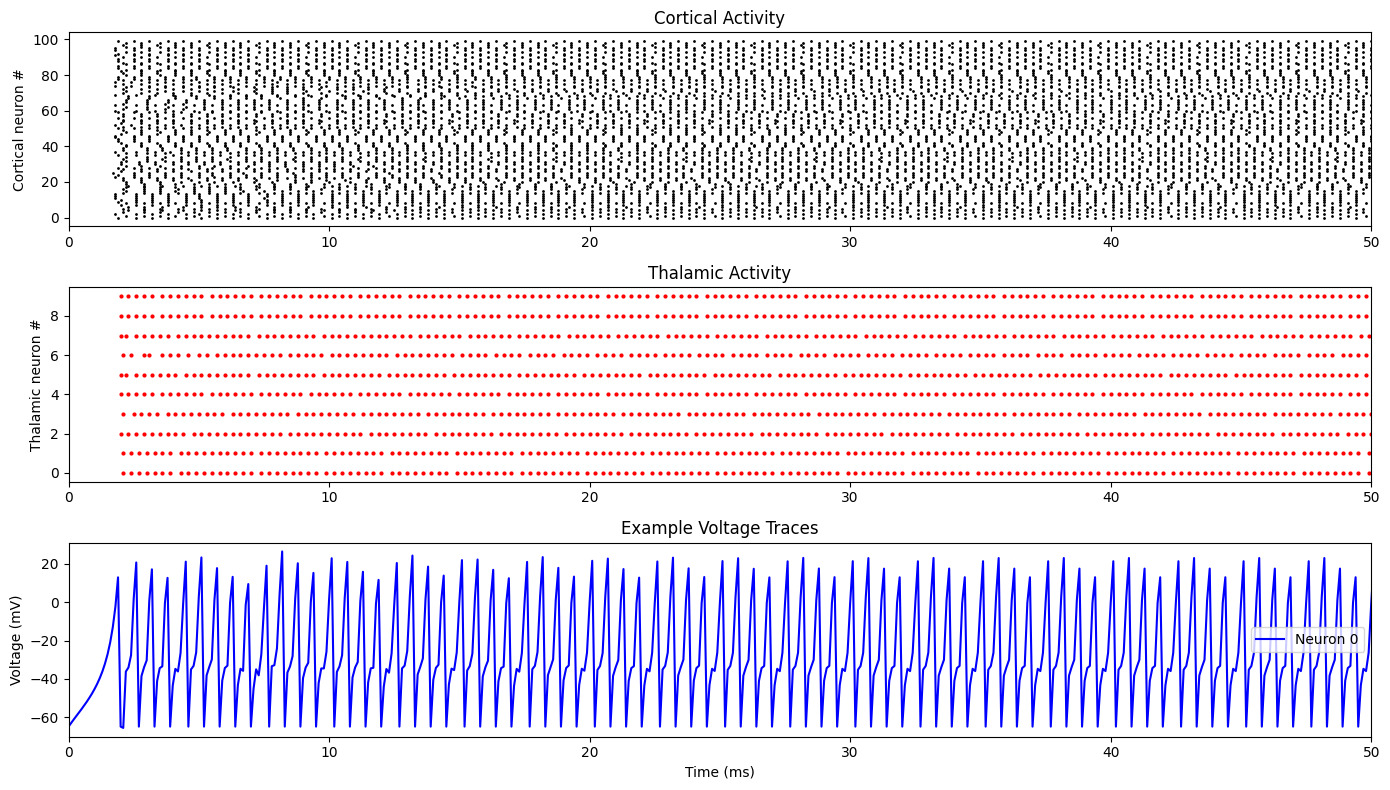

Cortical spikes: 78668
Thalamic spikes: 15794


In [ ]:
from brian2 import *
import numpy as np

# Model written by Claude and debugged by Copilot
start_scope()

# Izhikevich neurons
eqs = '''
dv/dt = (0.04*(v/mV)**2 + 5*(v/mV) + 140 - (u/mV) + I/pA) * (mV/ms) : volt
du/dt = a*(b*(v/mV) - u/mV) * (volt / ms) : volt
I : amp
a : 1
b : 1
c : volt
d : volt
'''

eqs_obj = Equations(eqs)
eqs_obj._check_units = False

# 100 Cortical neurons
Cortical = NeuronGroup(100, eqs_obj,
                       threshold='v > 30*mV',
                       reset='v = c; u = u + d',
                       method='euler')
Cortical.a = 0.02
Cortical.b = 0.2
Cortical.c = -65*mV
Cortical.d = 8*mV
Cortical.v = -65*mV
Cortical.u = -13*mV
Cortical.I = '15*pA + 10*pA*rand()'

# 10 Higher-order thalamic neurons
HO_Thal = NeuronGroup(10, eqs_obj,
                      threshold='v > 30*mV',
                      reset='v = c; u = u + d',
                      method='euler')
HO_Thal.a = 0.02
HO_Thal.b = 0.2
HO_Thal.c = -65*mV
HO_Thal.d = 2*mV
HO_Thal.v = -65*mV
HO_Thal.u = -13*mV
HO_Thal.I = 0*pA

# Connectivity
# Cortex → Thalamus (10:1 convergence)
C_to_T = Synapses(Cortical, HO_Thal, on_pre='v += 20*mV')
C_to_T.connect(condition='j == i // 10')

# Thalamus → Cortex (1:10 divergence, broadcast)
T_to_C = Synapses(HO_Thal, Cortical, on_pre='v += 25*mV')
T_to_C.connect(condition='i == j // 10')

# Monitors
CM = SpikeMonitor(Cortical)
TM = SpikeMonitor(HO_Thal)
V_mon = StateMonitor(Cortical, 'v', record=[0, 50])

# Run
run(500*ms)

# Plot
figure(figsize=(14, 8))

subplot(3, 1, 1)
plot(CM.t/ms, CM.i, '.k', markersize=2)
ylabel('Cortical neuron #')
title('Cortical Activity')
xlim(0, 50)

subplot(3, 1, 2)
plot(TM.t/ms, TM.i, '.r', markersize=4)
ylabel('Thalamic neuron #')
title('Thalamic Activity')
xlim(0, 50)

subplot(3, 1, 3)
plot(V_mon.t/ms, V_mon.v[0]/mV, 'b', label='Neuron 0')

xlabel('Time (ms)')
ylabel('Voltage (mV)')
title('Example Voltage Traces')
legend()
xlim(0, 50)

tight_layout()
show()

print(f"Cortical spikes: {CM.count[:].sum()}")
print(f"Thalamic spikes: {TM.count[:].sum()}")